In [ ]:
import kagglehub
import os # Import os module

# Download latest version
path = kagglehub.dataset_download("nirmalsankalana/plantdoc-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'plantdoc-dataset' dataset.
Path to dataset files: /kaggle/input/plantdoc-dataset
Contents of base_path (/kaggle/input):
['plantdoc-dataset']
Contents of path (/kaggle/input/plantdoc-dataset):
['folder_renamer.py', 'file_renamer.py', 'test', 'train']


In [ ]:
import tensorflow as tf

# Check if GPU is available
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU is available: {gpu_devices}")
    # Optionally, set memory growth to avoid allocating all memory at once
    for device in gpu_devices:
        tf.config.experimental.set_memory_growth(device, True)
else:
    print("No GPU detected. The model will run on CPU.")

GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models

# Data Loading and Preprocessing
data_dir = path # Uses the 'path' variable from the download cell
img_height, img_width = 227, 227 # AlexNet standard input size
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

class_names = train_ds.class_names
num_classes = len(class_names)

# Prefetching for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 2922 files belonging to 2 classes.
Using 2338 files for training.
Found 2922 files belonging to 2 classes.
Using 584 files for validation.


In [ ]:
def build_alexnet(num_classes):
    model = models.Sequential([
        # Layer 1
        layers.Conv2D(96, (11, 11), strides=4, activation='relu', input_shape=(227, 227, 3)),
        layers.MaxPooling2D((3, 3), strides=2),
        layers.BatchNormalization(),

        # Layer 2
        layers.Conv2D(256, (5, 5), padding='same', activation='relu'),
        layers.MaxPooling2D((3, 3), strides=2),
        layers.BatchNormalization(),

        # Layer 3
        layers.Conv2D(384, (3, 3), padding='same', activation='relu'),

        # Layer 4
        layers.Conv2D(384, (3, 3), padding='same', activation='relu'),

        # Layer 5
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((3, 3), strides=2),
        layers.BatchNormalization(),

        # Flatten
        layers.Flatten(),

        # Layer 6 (FC)
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),

        # Layer 7 (FC)
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),

        # Layer 8 (Output)
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

alexnet_model = build_alexnet(num_classes)
alexnet_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

alexnet_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 27, 27, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,291,970 (222.37 MB)

 Trainable params: 58,290,754 (222.36 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [ ]:
# Training the model
epochs = 10
history = alexnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 62s 266ms/step - accuracy: 0.8601 - loss: 2.9968 - val_accuracy: 0.9144 - val_loss: 0.5207
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.8922 - loss: 0.4472 - val_accuracy: 0.8955 - val_loss: 0.3363
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.8986 - loss: 0.4074 - val_accuracy: 0.9144 - val_loss: 0.3135
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.9089 - loss: 0.3682 - val_accuracy: 0.9144 - val_loss: 0.3174
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9085 - loss: 0.3536 - val_accuracy: 0.9144 - val_loss: 0.3652
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9068 - loss: 0.3539 - val_accuracy: 0.9144 - val_loss: 0.3077
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9072 - loss: 0.3366 - val_accuracy: 0.9144 - val_loss: 0.3357
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.9080 - loss: 0.3634 - val_accuracy: 0.9144 -

In [ ]:
# Summarize Training Results
final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("--- Training Summary ---")
print(f"Final Training Accuracy: {final_train_accuracy:.4f}")
print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

--- Training Summary ---
Final Training Accuracy: 0.9046
Final Validation Accuracy: 0.8990
Final Training Loss: 0.3699
Final Validation Loss: 0.3318


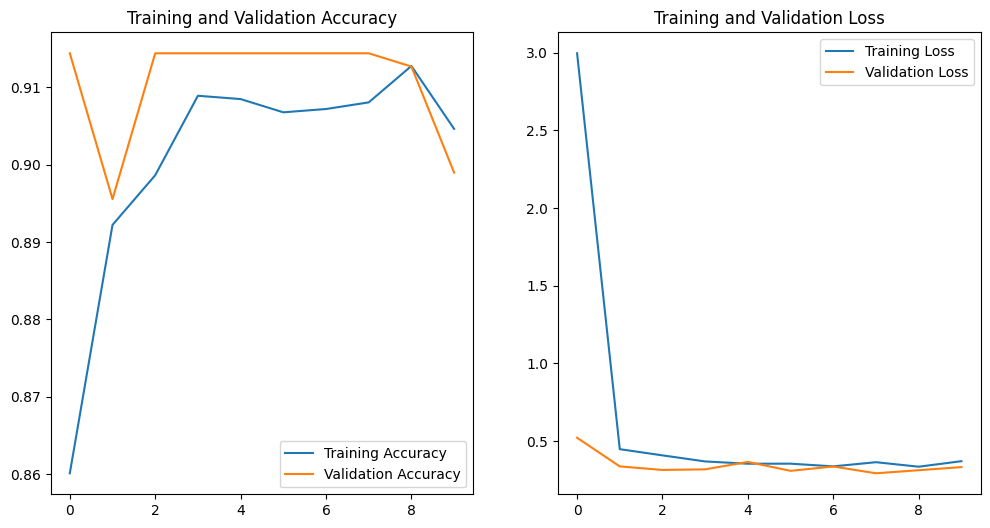

In [ ]:
import matplotlib.pyplot as plt

# Plot Training History
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()